In [2]:
# Load Gold ML tables from MSSQL
import pyodbc
import pandas as pd

from sqlalchemy import create_engine

conn = pyodbc.connect(
    "Driver={ODBC Driver 18 for SQL Server};"
    "Server=LAMOSKI;"
    "Database=RideMetrics;"
    "Trusted_Connection=yes;"
    "Encrypt=no;"
)
engine = create_engine("mssql+pyodbc://LAMOSKI/RideMetrics?driver=ODBC+Driver+18+for+SQL+Server&trusted_connection=yes&encrypt=no")

cursor = conn.cursor()
cursor.execute("SELECT @@VERSION")
print(cursor.fetchone())

df_ml_demand = pd.read_sql(
    'SELECT * FROM Gold.ML_Demand', engine)

df_ml_earnings = pd.read_sql(
    'SELECT * FROM Gold.ML_Earnings', engine)

print(f"Demand shape: {df_ml_demand.shape}")
print(f"Earnings shape: {df_ml_earnings.shape}")

('Microsoft SQL Server 2022 (RTM) - 16.0.1000.6 (X64) \n\tOct  8 2022 05:58:25 \n\tCopyright (C) 2022 Microsoft Corporation\n\tDeveloper Edition (64-bit) on Windows 10 Home 10.0 <X64> (Build 26200: ) (Hypervisor)\n',)
Demand shape: (4287, 12)
Earnings shape: (2691, 10)


DEMAND PREDICTION

In [3]:


# keeping only the relevant columns for ML model training
df_ml_demand = df_ml_demand[[
    'hour',
    'day_of_week',
    'month',
    'season',
    'distance',
    'duration',
    'demand_category'
]]

print(f"Shape: {df_ml_demand.shape}")
print(f"\nTarget distribution:")
print(df_ml_demand['demand_category'].value_counts())
print(f"\nNulls: {df_ml_demand.isnull().sum().sum()}")

Shape: (4287, 7)

Target distribution:
demand_category
Medium    2578
High      1231
Low        478
Name: count, dtype: int64

Nulls: 0


In [4]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
#encoding categorical variables
day_encoder = LabelEncoder()
season_encoder = LabelEncoder()
target_encoder = LabelEncoder()

#transforming categorical variables into numerical values
df_ml_demand['day_encoded'] = day_encoder.fit_transform(df_ml_demand['day_of_week'])
df_ml_demand['season_encoded'] = season_encoder.fit_transform(df_ml_demand['season'])
df_ml_demand['target_encoded'] = target_encoder.fit_transform(df_ml_demand['demand_category'])

#defining features and target variable
features = ['hour', 'day_encoded', 'month', 'season_encoded', 'distance', 'duration']
x = df_ml_demand[features]
y = df_ml_demand['target_encoded']



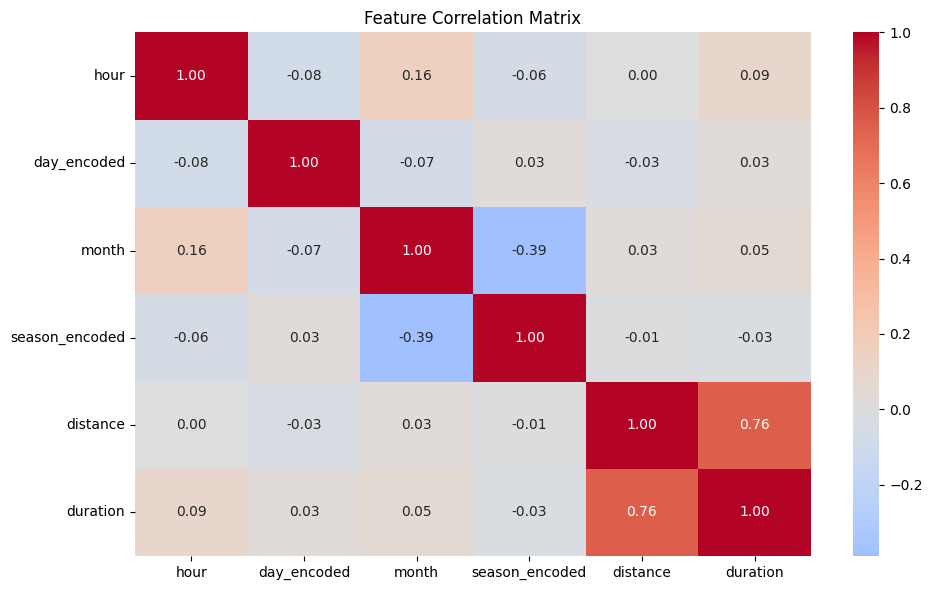

                 hour  day_encoded  month  season_encoded  distance  duration
hour            1.000       -0.077  0.158          -0.062     0.001     0.090
day_encoded    -0.077        1.000 -0.068           0.026    -0.032     0.031
month           0.158       -0.068  1.000          -0.389     0.031     0.052
season_encoded -0.062        0.026 -0.389           1.000    -0.011    -0.030
distance        0.001       -0.032  0.031          -0.011     1.000     0.755
duration        0.090        0.031  0.052          -0.030     0.755     1.000


In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix
corr = df_ml_demand[features].corr()

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(corr, annot=True, fmt='.2f', 
            cmap='coolwarm', center=0, ax=ax)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

print(corr.round(3))

In [6]:
#splitting the data into training and testing sets
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42, stratify=y)

print(f"Training set: {x_train.shape}")
print(f"Test set:     {x_test.shape}")

Training set: (3429, 6)
Test set:     (858, 6)


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,f1_score

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Logistic Regression (baseline model)
lr_model = LogisticRegression(
    class_weight = 'balanced',
    max_iter = 2000,
    random_state = 4
    
)
lr_model.fit(x_train_scaled, y_train)

#Random Forest (primary model)
rf_model = RandomForestClassifier(
    class_weight = 'balanced',
    n_estimators = 100,
    max_depth = 5,
    random_state = 4
)
rf_model.fit(x_train, y_train)

#XGBoost (benchmark model)
xgb_model = XGBClassifier(
    n_estimators = 50,
    learning_rate = 0.1,
    max_depth = 3,
    random_state = 4,
    eval_metric = 'mlogloss'
)
xgb_model.fit(x_train, y_train)

models = {
    'Logistic Regression' : (lr_model,x_test_scaled),
    'Random Forest' : (rf_model,x_test),
    'XGBoost' : (xgb_model,x_test)
}

results = []
for name, (model, x_test_data) in models.items():
    y_pred = model.predict(x_test_data)
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred, average='weighted')
    })
print("\nModel Evaluation Results:")
print(pd.DataFrame(results).set_index('Model').round(4))


Model Evaluation Results:
                     Accuracy  F1-Score
Model                                  
Logistic Regression    0.4534    0.4640
Random Forest          0.8030    0.8044
XGBoost                0.9569    0.9525


              precision    recall  f1-score   support

        High       1.00      1.00      1.00       246
         Low       1.00      0.61      0.76        96
      Medium       0.93      1.00      0.97       516

    accuracy                           0.96       858
   macro avg       0.98      0.87      0.91       858
weighted avg       0.96      0.96      0.95       858



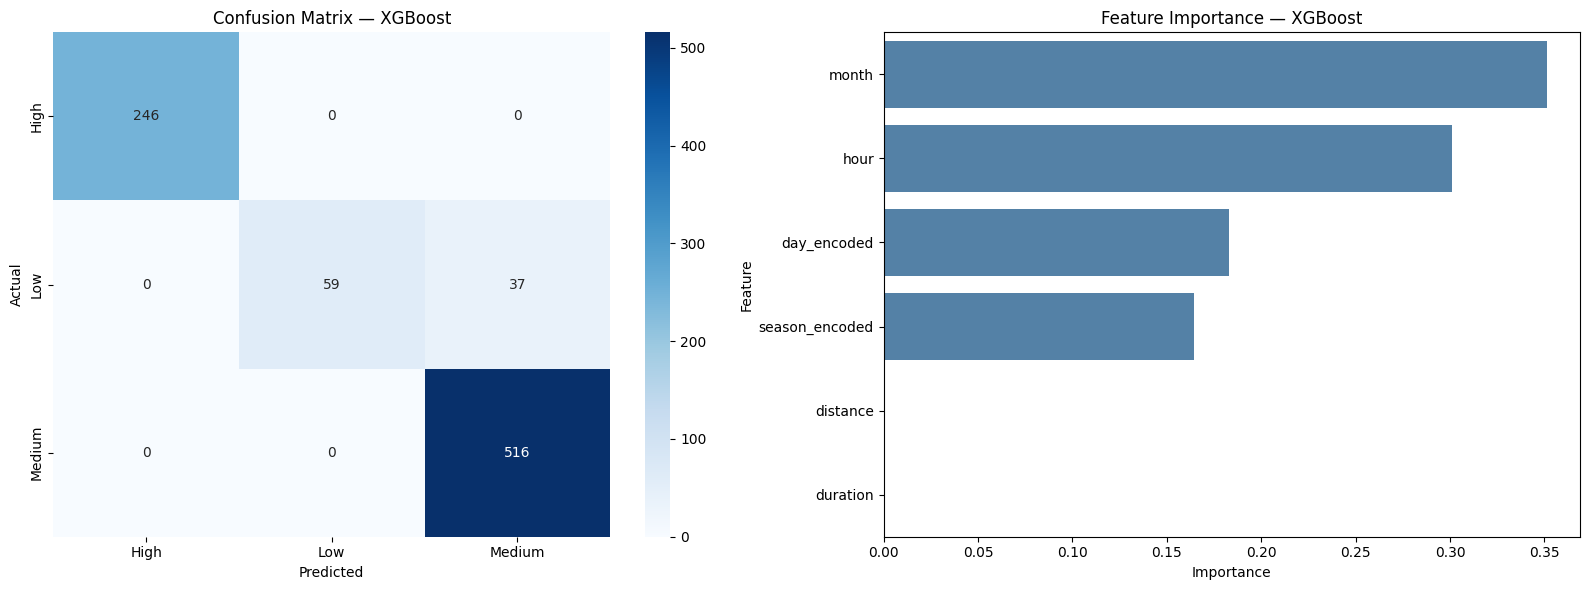

          Feature  Importance
0           month    0.351282
1            hour    0.301258
2     day_encoded    0.183125
3  season_encoded    0.164335
4        distance    0.000000
5        duration    0.000000


In [8]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_xgb = xgb_model.predict(x_test)

# Classification report
print(classification_report(
    y_test, y_pred_xgb,
    target_names=target_encoder.classes_
))

# Confusion matrix + Feature importance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_encoder.classes_,
            yticklabels=target_encoder.classes_,
            ax=axes[0])
axes[0].set_title('Confusion Matrix — XGBoost')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

sns.barplot(data=importance_df, x='Importance',
            y='Feature', color='steelblue', ax=axes[1])
axes[1].set_title('Feature Importance — XGBoost')

plt.tight_layout()
plt.show()

print(importance_df.reset_index(drop=True).to_string())

In [9]:
features_final = ['hour', 'day_encoded', 'month', 'season_encoded']

X = df_ml_demand[features_final]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1: {f1_score(y_test, y_pred, average='weighted'):.4f}")

Accuracy: 0.9569
F1: 0.9525


In [10]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    xgb_model, X, y,
    cv=5, scoring='f1_weighted'
)
print(f"CV F1 Scores: {cv_scores.round(4)}")
print(f"Mean: {cv_scores.mean():.4f}")
print(f"Std:  {cv_scores.std():.4f}")

CV F1 Scores: [0.8581 0.8552 0.9313 0.9819 0.9905]
Mean: 0.9234
Std:  0.0581


EARNINGS PREDICTION


In [11]:
df_ml_earnings.head(3)

,request_time,hour,day_of_week,month,season,distance_metres,duration_seconds,earning_category,hourly_earnings,is_event_day
0,2024-09-23 16:19:48,16,Monday,9,Autumn,2857.09,438.0,Medium,32.98,0
1,2024-09-23 16:33:01,16,Monday,9,Autumn,2914.04,445.0,Medium,32.98,0
2,2024-09-23 16:40:27,16,Monday,9,Autumn,2086.20,387.0,Medium,32.98,0


In [12]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
#encoding categorical variables
day_encoder = LabelEncoder()
season_encoder = LabelEncoder()
target_encoder = LabelEncoder()

#transforming categorical variables into numerical values
df_ml_earnings['day_encoded'] = day_encoder.fit_transform(df_ml_earnings['day_of_week'])
df_ml_earnings['season_encoded'] = season_encoder.fit_transform(df_ml_earnings['season'])
df_ml_earnings['target_encoded'] = target_encoder.fit_transform(df_ml_earnings['earning_category'])

#defining features and target variable
earnings_features = ['hour', 'day_encoded', 'month', 'season_encoded', 'distance_metres', 'duration_seconds','is_event_day']
x = df_ml_earnings[earnings_features]
y = df_ml_earnings['target_encoded']

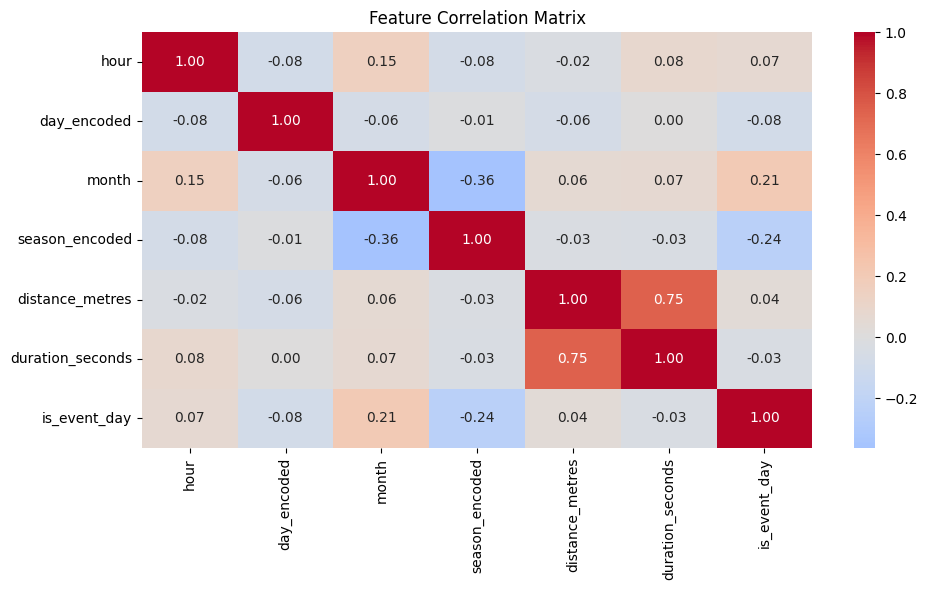

                   hour  day_encoded  month  season_encoded  distance_metres  \
hour              1.000       -0.077  0.153          -0.076           -0.024   
day_encoded      -0.077        1.000 -0.065          -0.008           -0.063   
month             0.153       -0.065  1.000          -0.363            0.058   
season_encoded   -0.076       -0.008 -0.363           1.000           -0.027   
distance_metres  -0.024       -0.063  0.058          -0.027            1.000   
duration_seconds  0.081        0.003  0.069          -0.032            0.747   
is_event_day      0.073       -0.080  0.207          -0.240            0.037   

                  duration_seconds  is_event_day  
hour                         0.081         0.073  
day_encoded                  0.003        -0.080  
month                        0.069         0.207  
season_encoded              -0.032        -0.240  
distance_metres              0.747         0.037  
duration_seconds             1.000        -0.032  
is

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix
corr = df_ml_earnings[earnings_features].corr()

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(corr, annot=True, fmt='.2f', 
            cmap='coolwarm', center=0, ax=ax)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

print(corr.round(3))

In [14]:
#splitting the data into training and testing sets
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42, stratify=y)

print(f"Training set: {x_train.shape}")
print(f"Test set:     {x_test.shape}")

Training set: (2152, 7)
Test set:     (539, 7)


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,f1_score

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Logistic Regression (baseline model)
lr_model = LogisticRegression(
    class_weight = 'balanced',
    max_iter = 2000,
    random_state = 4
    
)
lr_model.fit(x_train_scaled, y_train)

#Random Forest (primary model)
rf_model = RandomForestClassifier(
    class_weight = 'balanced',
    n_estimators = 100,
    max_depth = 5,
    random_state = 4
)
rf_model.fit(x_train, y_train)

#XGBoost (benchmark model)
xgb_model = XGBClassifier(
    n_estimators = 50,
    learning_rate = 0.1,
    max_depth = 5,
    random_state = 4,
    eval_metric = 'mlogloss'
)
xgb_model.fit(x_train, y_train)

models = {
    'Logistic Regression' : (lr_model,x_test_scaled),
    'Random Forest' : (rf_model,x_test),
    'XGBoost' : (xgb_model,x_test)
}

results = []
for name, (model, x_test_data) in models.items():
    y_pred = model.predict(x_test_data)
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred, average='weighted')
    })
print("\nModel Evaluation Results:")
print(pd.DataFrame(results).set_index('Model').round(4))


Model Evaluation Results:
                     Accuracy  F1-Score
Model                                  
Logistic Regression    0.4508    0.4834
Random Forest          0.4471    0.4783
XGBoost                0.6475    0.5384


In [16]:
print(x.columns.tolist())
print(x.shape)
print(df_ml_earnings['earning_category'].value_counts())

['hour', 'day_encoded', 'month', 'season_encoded', 'distance_metres', 'duration_seconds', 'is_event_day']
(2691, 7)
earning_category
High      1736
Low        556
Medium     399
Name: count, dtype: int64


In [17]:
def calculate_demand_score(hour, day, season):
    score = 0
    if hour in [14, 15, 16, 17, 7, 8]:
        score += 3
    elif hour in [0, 1, 2, 3, 4, 21, 22, 23]:
        score += 0
    else:
        score += 1
    if day in ['Friday', 'Saturday']:
        score += 2
    elif day in ['Wednesday']:
        score += 0
    else:
        score += 1
    if season in ['Autumn']:
        score += 2
    elif season in ['Winter']:
        score += 1
    else:
        score += 0
    return score

df_ml_earnings['demand_score'] = df_ml_earnings.apply(
    lambda x: calculate_demand_score(
        x['hour'], x['day_of_week'], x['season']
    ), axis=1
)

print(df_ml_earnings['demand_score'].value_counts().sort_index())

demand_score
1     35
2    164
3    469
4    677
5    756
6    396
7    194
Name: count, dtype: int64


In [18]:
# Add demand score to earnings features
df_ml_earnings['demand_score'] = df_ml_earnings.apply(
    lambda x: calculate_demand_score(
        x['hour'], x['day_of_week'], x['season']
    ), axis=1
)

features_earnings = [
    'hour', 'day_encoded', 'month',
    'season_encoded', 'distance_metres',
    'duration_seconds', 'is_event_day',
    'demand_score'
]

X = df_ml_earnings[features_earnings]
y = df_ml_earnings['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

xgb_model2.fit(X_train, y_train)
y_pred = xgb_model2.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1: {f1_score(y_test, y_pred, average='weighted'):.4f}")

KeyError: 'target'